# 03 — Baselines & Leak-Free Comparison Harness (Gemcitabine)

This notebook builds the modelling foundation. Everything here is **leak-free**:
scaling and feature selection are fit **inside each CV fold only**.

**Driving question — the tissue confound.** The PCA in notebook 02 showed blood cancers
(myeloid + lymphoid) form a distinct, more-sensitive cluster. Tissue type therefore predicts
*both* the expression profile and the IC50. So before claiming "genes predict drug response"
we must ask: **how much is just tissue, and what do genes add on top?**

We answer this with a comparison harness, all under the same 5-fold stratified CV:

| # | Model | What it tells us |
|---|---|---|
| 0 | Lineage-only → Ridge | The confound baseline — signal from tissue alone |
| 1 | All genes → Ridge | Sound linear model for p≫n; discards nothing |
| 2 | Top-N genes (MI) → Ridge | Interpretable subset; sweep N |
| 3 | ElasticNetCV | Embedded selection; can see past the lineage shortcut |
| — | PCA-50 → Ridge | Representation contrast (loses gene interpretability) |

We then break performance down **by lineage** and re-run on **solid tumours only** (blood
cancers removed) to check the model learned *mechanism*, not the *blood = sensitive* shortcut.

The notebook persists arrays (`X`, `y`, folds, selected genes) to `output/` so notebooks 04–05
load instantly without re-reading the 518 MB expression matrix.

---
## Section 0 — Imports & Config

In [1]:
import os, sys, json, time, warnings

# Notebooks execute with cwd=notebooks/, so add the repo root to the path to
# import the shared merge logic. src/data.py is the single source of truth --
# never re-inline the merge here (see CLAUDE.md).
sys.path.insert(0, os.path.abspath('..'))
from src import data as sdata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR  = "../data/"
GDSC_PATH  = DATA_DIR + "GDSC2_fitted_dose_response_27Oct23.csv"
MODEL_PATH = DATA_DIR + "Model.csv"
EXPR_PATH  = DATA_DIR + "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv"

OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Hyperparameters
VARIANCE_THRESHOLD = 0.1
MIN_LINEAGE_COUNT  = 5
N_SPLITS           = 5
RANDOM_SEED        = 42
KS                 = [500, 1000, 2000]      # top-N gene sweep
RIDGE_ALPHAS       = np.logspace(-1, 4, 10)
TARGET_DRUG        = "Gemcitabine"
BLOOD_LINEAGES     = ["Lymphoid", "Myeloid"]

rng = np.random.RandomState(RANDOM_SEED)
print("Setup complete. Output ->", os.path.abspath(OUTPUT_DIR))

Setup complete. Output -> /app/output


---
## Section 1 — Rebuild Merge & Variance Filter

Replicates notebook 02 (Sections 1–4) exactly: 3-way merge, dedup by
`['COSMIC_ID','DRUG_NAME','ModelID']` only, filter expression to
`IsDefaultEntryForModel == 'Yes'`, then drop genes with variance < 0.1.

> **Note on leakage:** the variance filter uses only `X` (not `y`), so applying it once on all
> data is fine. Label-aware steps (MI selection, scaling) happen *inside folds* later.

In [2]:
# The 3-way join, dedup and variance filter all live in src/data.py, so this
# notebook and notebook 02 cannot drift apart. Rules enforced there:
#   - expression filtered to IsDefaultEntryForModel == "Yes" (string, not bool)
#   - dedup groups by COSMIC_ID/DRUG_NAME/ModelID only (NaN TCGA_DESC drops rows)
gdsc        = sdata.load_gdsc2(DATA_DIR)
model_clean = sdata.load_model_bridge(DATA_DIR)

print("Loading expression matrix (~30s)...")
expr_final, gene_cols = sdata.load_expression(DATA_DIR)

merged = sdata.build_merged(gdsc, model_clean, expr_final, target_drug=TARGET_DRUG)

# Variance filter is unsupervised (never sees y), so it is safe outside the CV loop.
X, y, gene_names, meta = sdata.build_drug_matrix(
    merged, gene_cols, variance_threshold=VARIANCE_THRESHOLD)

print(f"Cell lines: {X.shape[0]}  |  genes after variance filter: {X.shape[1]}")
print(f"y: mean={y.mean():.3f}, std={y.std():.3f}, range=[{y.min():.2f}, {y.max():.2f}]")

Loading expression matrix (~30s)...


Cell lines: 694  |  genes after variance filter: 16820
y: mean=-0.629, std=3.032, range=[-6.34, 7.72]


---
## Section 2 — Lineage Labels & Stratified Splits

`OncotreeLineage` drives stratification (it has no nulls after fillna, unlike `TCGA_DESC`).
Rare lineages (< 5 cell lines) are collapsed to `"Other"` so every class survives a 5-fold
split. We persist the fold indices and an 80/20 holdout so notebooks 04–05 use identical splits.

In [3]:
# Alias kept so later cells can still call collapse_rare(...) directly.
collapse_rare = sdata.collapse_rare_lineages

meta, lineage_encoded, le = sdata.add_lineage_columns(meta, blood_lineages=BLOOD_LINEAGES)
lineage_label = meta["lineage_label"].values

print(f"Lineage classes: {len(le.classes_)}")
print(f"Blood-cancer cell lines: {meta['is_blood'].sum()} / {len(meta)}")

# 5-fold stratified CV
folds = sdata.make_folds(X, lineage_encoded, n_splits=N_SPLITS, random_state=RANDOM_SEED)

# 80/20 stratified holdout (for fitting final models in nb 04/05)
holdout_train_idx, holdout_test_idx = sdata.make_holdout(
    y, lineage_encoded, test_size=0.2, random_state=RANDOM_SEED)

# Persist everything downstream notebooks need (output/ is gitignored)
np.save(os.path.join(OUTPUT_DIR, "X_var_filtered.npy"), X)
np.save(os.path.join(OUTPUT_DIR, "y.npy"), y)
with open(os.path.join(OUTPUT_DIR, "gene_names.json"), "w") as f:
    json.dump(gene_names, f)
meta.to_csv(os.path.join(OUTPUT_DIR, "meta.csv"), index=False)
np.savez(os.path.join(OUTPUT_DIR, "cv_folds.npz"),
         **{f"train_{i}": tr for i, (tr, te) in enumerate(folds)},
         **{f"test_{i}": te for i, (tr, te) in enumerate(folds)})
np.savez(os.path.join(OUTPUT_DIR, "holdout_split.npz"),
         train=holdout_train_idx, test=holdout_test_idx)
print("Saved X/y/folds/meta to output/.")

Lineage classes: 23
Blood-cancer cell lines: 115 / 694


Saved X/y/folds/meta to output/.


---
## Section 3 — Run the Comparison Harness

Manual CV loop so we can (a) compute mutual information **once per fold** and reuse it across
all `k`, (b) collect out-of-fold predictions for pooled + per-lineage metrics. Every label-aware
transform (`StandardScaler`, `mutual_info_regression`, `RidgeCV`, `ElasticNetCV`, `PCA`) is fit on
the **training fold only**.

In [4]:
model_names = (["Lineage-only (Ridge)", "All genes (Ridge)"]
               + [f"Top-{k} MI (Ridge)" for k in KS]
               + ["ElasticNetCV", "PCA-50 (Ridge)"])

n = X.shape[0]
oof          = {m: np.full(n, np.nan) for m in model_names}
fold_metrics = {m: [] for m in model_names}     # (rmse, r2, pearson_r) per fold
selected_idx = {k: [] for k in KS}              # selected gene indices per fold

def _rmse(yt, yp):
    return float(np.sqrt(mean_squared_error(yt, yp)))

def record(name, te, yt, pred):
    oof[name][te] = pred
    fold_metrics[name].append(
        (_rmse(yt, pred), r2_score(yt, pred), float(np.corrcoef(yt, pred)[0, 1])))

for fi, (tr, te) in enumerate(folds, 1):
    t0 = time.time()
    Xtr, Xte = X[tr], X[te]
    ytr, yte = y[tr], y[te]
    lin_tr, lin_te = lineage_encoded[tr].reshape(-1, 1), lineage_encoded[te].reshape(-1, 1)

    scaler = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

    # 0 — lineage only
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(lin_tr)
    m0 = RidgeCV(alphas=RIDGE_ALPHAS).fit(ohe.transform(lin_tr), ytr)
    record("Lineage-only (Ridge)", te, yte, m0.predict(ohe.transform(lin_te)))

    # 1 — all genes
    m1 = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xtr_s, ytr)
    record("All genes (Ridge)", te, yte, m1.predict(Xte_s))

    # 2 — top-N MI (compute MI once, reuse for every k)
    mi    = mutual_info_regression(Xtr_s, ytr, random_state=RANDOM_SEED)
    order = np.argsort(mi)[::-1]
    for k in KS:
        idx = order[:k]
        selected_idx[k].append(idx)
        mk = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xtr_s[:, idx], ytr)
        record(f"Top-{k} MI (Ridge)", te, yte, mk.predict(Xte_s[:, idx]))

    # 3 — ElasticNetCV (embedded selection)
    enet = ElasticNetCV(l1_ratio=0.5, n_alphas=20, cv=3, max_iter=2000, tol=1e-2,
                        random_state=RANDOM_SEED, n_jobs=-1, selection="random").fit(Xtr_s, ytr)
    record("ElasticNetCV", te, yte, enet.predict(Xte_s))

    # PCA contrast
    pca = PCA(n_components=50, random_state=RANDOM_SEED).fit(Xtr_s)
    mp  = RidgeCV(alphas=RIDGE_ALPHAS).fit(pca.transform(Xtr_s), ytr)
    record("PCA-50 (Ridge)", te, yte, mp.predict(pca.transform(Xte_s)))

    print(f"Fold {fi}/{N_SPLITS} done in {time.time()-t0:.0f}s")

print("Harness complete.")

Fold 1/5 done in 134s


Fold 2/5 done in 123s


Fold 3/5 done in 105s


Fold 4/5 done in 93s


Fold 5/5 done in 97s
Harness complete.


---
## Section 4 — Results Table

Mean ± std across folds, plus pooled out-of-fold R² (a single honest estimate on all 694).

In [5]:
rows = []
for m in model_names:
    arr = np.array(fold_metrics[m])                       # (n_folds, 3)
    rows.append({
        "model": m,
        "RMSE_mean": arr[:, 0].mean(), "RMSE_std": arr[:, 0].std(),
        "R2_mean":   arr[:, 1].mean(), "R2_std":   arr[:, 1].std(),
        "PearsonR_mean": arr[:, 2].mean(),
        "R2_pooled_oof": r2_score(y, oof[m]),
    })
comparison = pd.DataFrame(rows).sort_values("R2_pooled_oof", ascending=False).reset_index(drop=True)
comparison.to_csv(os.path.join(OUTPUT_DIR, "model_comparison.csv"), index=False)
comparison

,model,RMSE_mean,RMSE_std,R2_mean,R2_std,PearsonR_mean,R2_pooled_oof
0,ElasticNetCV,2.2459,0.1748,0.4476,0.0493,0.6780,0.4479
1,All genes (Ridge),2.4169,0.1511,0.3595,0.0501,0.6065,0.3620
2,Top-1000 MI (Ridge),2.4273,0.1719,0.3539,0.0599,0.6019,0.3558
3,Top-500 MI (Ridge),2.4281,0.1613,0.3524,0.0674,0.6008,0.3557
4,Top-2000 MI (Ridge),2.4500,0.1541,0.3431,0.0337,0.5951,0.3444
5,PCA-50 (Ridge),2.4680,0.1625,0.3327,0.0484,0.5831,0.3344
6,Lineage-only (Ridge),2.7106,0.0877,0.1939,0.0365,0.4512,0.2000


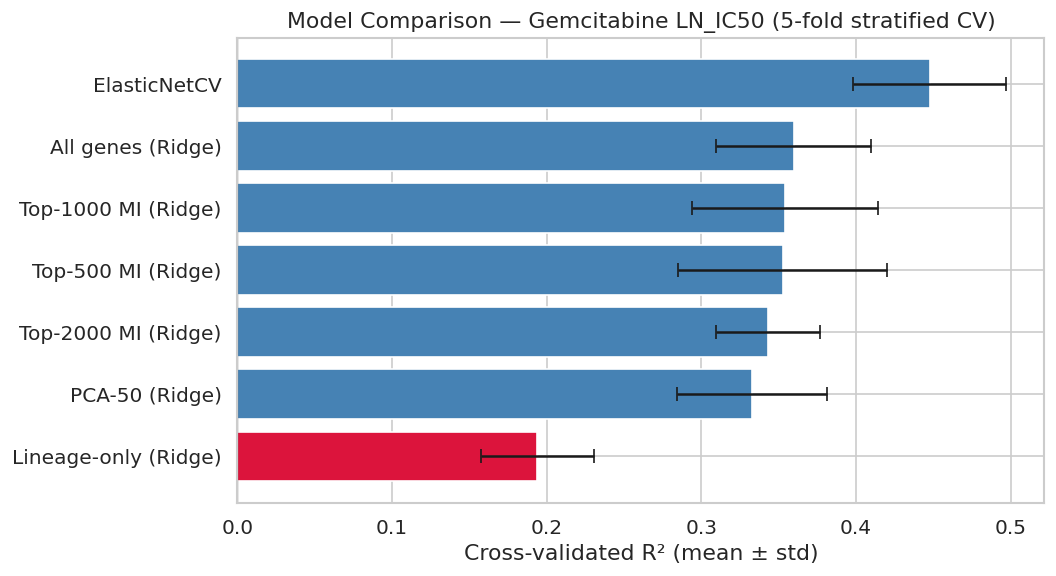

In [6]:
# Bar chart: pooled R2 with fold mean +/- std error bars
order_plot = comparison["model"].tolist()
r2_mean = [comparison.loc[comparison.model == m, "R2_mean"].iloc[0] for m in order_plot]
r2_std  = [comparison.loc[comparison.model == m, "R2_std"].iloc[0]  for m in order_plot]

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["crimson" if m.startswith("Lineage") else "steelblue" for m in order_plot]
ax.barh(order_plot[::-1], r2_mean[::-1], xerr=r2_std[::-1],
        color=colors[::-1], edgecolor="white", capsize=4)
ax.set_xlabel("Cross-validated R² (mean ± std)")
ax.set_title("Model Comparison — Gemcitabine LN_IC50 (5-fold stratified CV)")
ax.axvline(0, color="grey", lw=0.8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison_r2.png"), dpi=150, bbox_inches="tight")
plt.show()

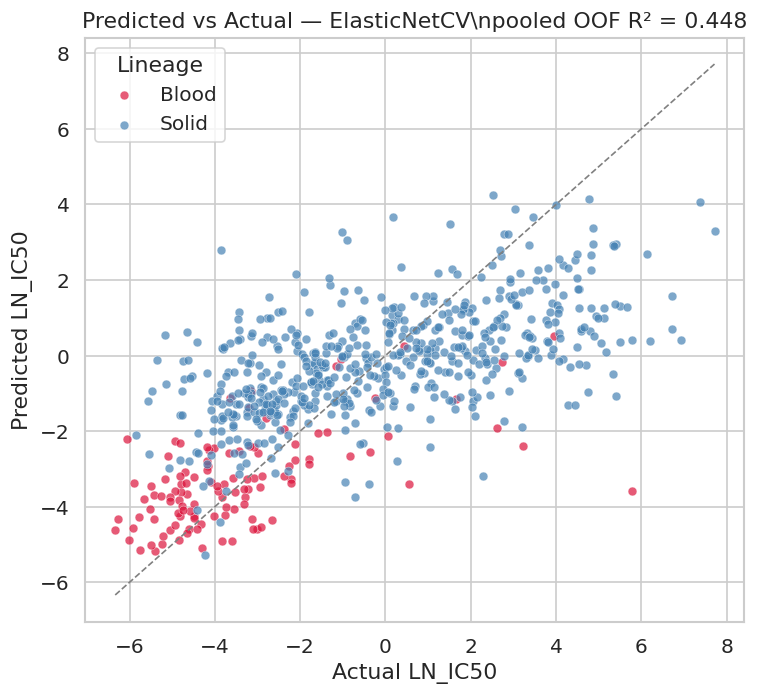

Best model: ElasticNetCV


In [7]:
# Predicted vs actual for the best model (pooled OOF), coloured by blood/solid
best_model = comparison.iloc[0]["model"]
pred = oof[best_model]
fig, ax = plt.subplots(figsize=(6.5, 6))
for flag, c, lbl in [(True, "crimson", "Blood"), (False, "steelblue", "Solid")]:
    mask = meta["is_blood"].values == flag
    ax.scatter(y[mask], pred[mask], s=28, alpha=0.7, color=c, edgecolors="white",
               linewidths=0.3, label=lbl)
lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
ax.plot(lims, lims, "--", color="grey", lw=1)
ax.set_xlabel("Actual LN_IC50"); ax.set_ylabel("Predicted LN_IC50")
ax.set_title(f"Predicted vs Actual — {best_model}\\npooled OOF R² = {r2_score(y, pred):.3f}")
ax.legend(title="Lineage")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "predicted_vs_actual_best.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Best model:", best_model)

---
## Section 5 — Performance by Lineage

Using the best model's out-of-fold predictions, we compute R² within each lineage. If the model
is merely exploiting the blood-cancer shortcut, solid-tumour lineages will have weak/negative R².

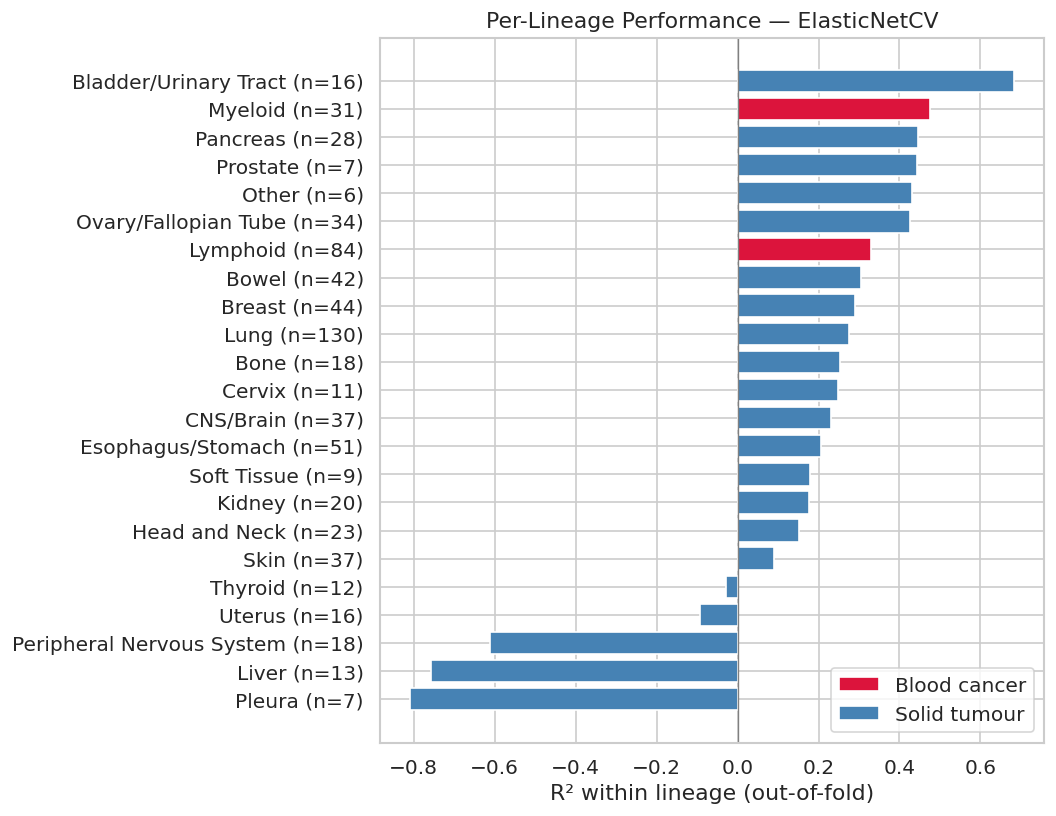

,lineage,n,R2,RMSE,is_blood
0,Bladder/Urinary Tract,16,0.6836,1.7186,False
1,Myeloid,31,0.4753,1.1421,True
2,Pancreas,28,0.4460,1.9475,False
3,Prostate,7,0.4440,1.2991,False
4,Other,6,0.4321,2.0798,False
5,Ovary/Fallopian Tube,34,0.4272,2.3613,False
6,Lymphoid,84,0.3306,1.9247,True
7,Bowel,42,0.3062,2.0605,False
8,Breast,44,0.2898,2.6843,False
9,Lung,130,0.2763,2.2643,False


In [8]:
best_pred = oof[best_model]
per_lineage = []
for lbl in sorted(meta["lineage_label"].unique()):
    mask = (meta["lineage_label"].values == lbl)
    if mask.sum() >= MIN_LINEAGE_COUNT:
        per_lineage.append({
            "lineage": lbl, "n": int(mask.sum()),
            "R2": r2_score(y[mask], best_pred[mask]),
            "RMSE": _rmse(y[mask], best_pred[mask]),
            "is_blood": lbl in BLOOD_LINEAGES,
        })
per_lineage = pd.DataFrame(per_lineage).sort_values("R2", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ["crimson" if b else "steelblue" for b in per_lineage["is_blood"]]
ax.barh(per_lineage["lineage"][::-1] + " (n=" + per_lineage["n"].astype(str)[::-1] + ")",
        per_lineage["R2"][::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("R² within lineage (out-of-fold)")
ax.set_title(f"Per-Lineage Performance — {best_model}")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="crimson", label="Blood cancer"),
                   Patch(facecolor="steelblue", label="Solid tumour")], loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "performance_by_lineage.png"), dpi=150, bbox_inches="tight")
plt.show()
per_lineage

---
## Section 6 — Solid-Tumour-Only Sensitivity Check

The decisive test for the confound: remove blood cancers and re-run. If genes still predict
within solid tumours, the model learned **mechanism**, not just *blood = sensitive*.

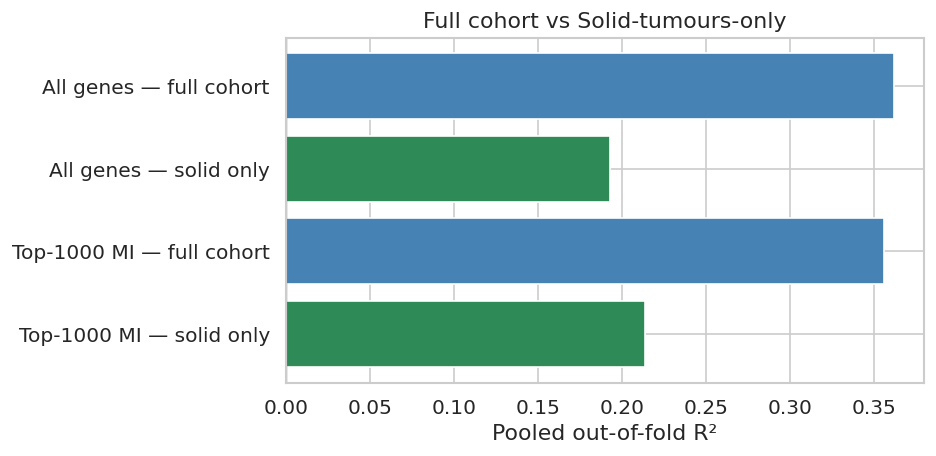

,setting,R2_pooled
0,All genes — full cohort,0.3620
1,All genes — solid only,0.1931
2,Top-1000 MI — full cohort,0.3558
3,Top-1000 MI — solid only,0.2137


In [9]:
solid = ~meta["is_blood"].values
Xs, ys = X[solid], y[solid]
lin_s  = collapse_rare(meta.loc[solid, "lineage_label"].values)   # recollapse for stratify
lin_s_enc = LabelEncoder().fit_transform(lin_s)

best_k = int([m.split("-")[1].split(" ")[0] for m in [best_model] if "MI" in best_model][0]) \
         if "MI" in best_model else KS[len(KS)//2]

def cv_eval(Xd, yd, strat, mode, k=None):
    skf2 = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_SEED)
    pred = np.full(len(yd), np.nan)
    for tr, te in skf2.split(Xd, strat):
        sc = StandardScaler().fit(Xd[tr])
        Xtr_s, Xte_s = sc.transform(Xd[tr]), sc.transform(Xd[te])
        if mode == "all":
            mdl = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xtr_s, yd[tr])
            pred[te] = mdl.predict(Xte_s)
        else:  # top-k MI
            mi = mutual_info_regression(Xtr_s, yd[tr], random_state=RANDOM_SEED)
            idx = np.argsort(mi)[::-1][:k]
            mdl = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xtr_s[:, idx], yd[tr])
            pred[te] = mdl.predict(Xte_s[:, idx])
    return r2_score(yd, pred)

res = {
    "All genes — full cohort":  r2_score(y, oof["All genes (Ridge)"]),
    "All genes — solid only":   cv_eval(Xs, ys, lin_s_enc, "all"),
    f"Top-{best_k} MI — full cohort": r2_score(y, oof[f"Top-{best_k} MI (Ridge)"]),
    f"Top-{best_k} MI — solid only":  cv_eval(Xs, ys, lin_s_enc, "topk", best_k),
}
solid_df = pd.DataFrame({"setting": list(res), "R2_pooled": list(res.values())})

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["steelblue" if "full" in s else "seagreen" for s in solid_df["setting"]]
ax.barh(solid_df["setting"][::-1], solid_df["R2_pooled"][::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Pooled out-of-fold R²")
ax.set_title("Full cohort vs Solid-tumours-only")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "solid_tumor_only_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
solid_df

---
## Section 7 — Consensus Selected Genes & Biology Peek

For the best top-N model, which genes are selected consistently across folds? And do the known
Gemcitabine markers **DCK** / **SLC29A1** show up — or does multivariate selection still bury
them under lineage markers (as univariate Pearson did in notebook 02)?

In [10]:
sel_k = best_k if best_k in selected_idx else KS[len(KS)//2]
from collections import Counter
counter = Counter()
for idx in selected_idx[sel_k]:
    counter.update(idx.tolist())
consensus = pd.DataFrame(
    [(gene_names[i], cnt) for i, cnt in counter.items()],
    columns=["gene", "n_folds_selected"]
).sort_values("n_folds_selected", ascending=False).reset_index(drop=True)
consensus.to_csv(os.path.join(OUTPUT_DIR, "selected_genes_consensus.csv"), index=False)

print(f"Top-{sel_k} model — {len(consensus)} unique genes selected across folds; "
      f"{(consensus['n_folds_selected'] == N_SPLITS).sum()} in all {N_SPLITS} folds.")

for marker in ["DCK", "SLC29A1"]:
    hit = consensus[consensus["gene"].str.startswith(marker + " ")]
    if len(hit):
        print(f"  {marker}: selected in {hit.iloc[0]['n_folds_selected']}/{N_SPLITS} folds")
    else:
        print(f"  {marker}: not in selected set (lineage signal dominates MI)")

consensus.head(20)

Top-1000 model — 2436 unique genes selected across folds; 203 in all 5 folds.
  DCK: selected in 2/5 folds
  SLC29A1: not in selected set (lineage signal dominates MI)


,gene,n_folds_selected
0,ARHGAP30 (257106),5
1,TSPAN6 (7105),5
2,TJP1 (7082),5
3,ITGAV (3685),5
4,NIBAN2 (64855),5
5,CUEDC1 (404093),5
6,NOS1AP (9722),5
7,CD276 (80381),5
8,LURAP1L (286343),5
9,DYNLT1 (6993),5


---
## Section 8 — Nested CV: Unbiased Hyperparameter Selection

Section 4 reports `Top-500/1000/2000 MI` as **three separate models** and `ElasticNetCV` with a
**fixed** `l1_ratio=0.5`. Reading the best `Top-K` off that table is a hidden form of tuning on the
test folds — the K that wins was chosen using the very out-of-fold data we then score on, so its R²
is **optimistically biased**.

**Nested CV** removes that bias. For each outer fold we run an inner 5-fold CV on the *training rows
only* to choose the hyperparameters, refit the winning config on the full outer-train, then score
once on the untouched outer-test:

- **Top-K MI → Ridge (nested):** inner CV picks `K* ∈ {500, 1000, 2000}` per fold.
- **ElasticNetCV (l1 tuned, nested):** `l1_ratio ∈ {.1, .5, .7, .9, .95, .99, 1}` **and** `alpha`
  chosen by its own inner CV on outer-train only.

Ridge `alpha` already used train-only `RidgeCV` (generalized CV), so it was never leaky and is kept
as-is. The deliverable is the **biased-vs-unbiased** table below: does honest tuning move the numbers?

> Runtime: this recomputes mutual information on ~16.8k genes across 5×5 inner splits (plus one refit
> per outer fold), so expect several minutes. `N_INNER` can drop to 3 without affecting unbiasedness.

In [11]:
# --- Section 8: nested CV harness ---------------------------------------------------
# For each OUTER fold we run an INNER 5-fold CV on the training rows only to pick the
# hyperparameters, refit the winning config on the full outer-train, and score once on
# the untouched outer-test. This removes the optimistic bias of choosing K / l1_ratio
# on the same folds used for scoring.
L1_GRID = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]
N_INNER = 5                                  # inner folds (drop to 3 if MI is too slow)

nested_names = ["Top-K MI (Ridge, nested)", "ElasticNetCV (l1 tuned, nested)"]
oof_nested   = {m: np.full(n, np.nan) for m in nested_names}
foldm_nested = {m: [] for m in nested_names}
hp_choices   = []

def _rec_nested(name, te, yt, pred):
    oof_nested[name][te] = pred
    foldm_nested[name].append(
        (_rmse(yt, pred), r2_score(yt, pred), float(np.corrcoef(yt, pred)[0, 1])))

for fi, (tr, te) in enumerate(folds, 1):
    t0 = time.time()
    Xtr, Xte = X[tr], X[te]
    ytr, yte = y[tr], y[te]
    strat_tr = lineage_encoded[tr]

    # scale on the full outer-train (reused for both outer-test refits below)
    scaler = StandardScaler().fit(Xtr)
    Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

    # ---- inner CV: choose K for Top-K MI -> Ridge (train-only) ----
    inner = StratifiedKFold(n_splits=N_INNER, shuffle=True, random_state=RANDOM_SEED)
    inner_scores = {k: [] for k in KS}
    for itr, ival in inner.split(Xtr, strat_tr):
        sc = StandardScaler().fit(Xtr[itr])
        Xi_tr, Xi_val = sc.transform(Xtr[itr]), sc.transform(Xtr[ival])
        mi_i  = mutual_info_regression(Xi_tr, ytr[itr], random_state=RANDOM_SEED)  # once, reuse per K
        order = np.argsort(mi_i)[::-1]
        for k in KS:
            idx = order[:k]
            mk  = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xi_tr[:, idx], ytr[itr])
            inner_scores[k].append(r2_score(ytr[ival], mk.predict(Xi_val[:, idx])))
    mean_inner = {k: float(np.mean(v)) for k, v in inner_scores.items()}
    k_star     = max(mean_inner, key=mean_inner.get)

    # refit MI+Ridge with K* on full outer-train, score outer-test
    mi_full  = mutual_info_regression(Xtr_s, ytr, random_state=RANDOM_SEED)
    idx_star = np.argsort(mi_full)[::-1][:k_star]
    m_mi     = RidgeCV(alphas=RIDGE_ALPHAS).fit(Xtr_s[:, idx_star], ytr)
    _rec_nested("Top-K MI (Ridge, nested)", te, yte, m_mi.predict(Xte_s[:, idx_star]))

    # ---- ElasticNet: l1_ratio + alpha chosen by inner CV on outer-train only ----
    enet = ElasticNetCV(l1_ratio=L1_GRID, n_alphas=20, cv=N_INNER, max_iter=2000, tol=1e-2,
                        random_state=RANDOM_SEED, n_jobs=-1, selection="random").fit(Xtr_s, ytr)
    _rec_nested("ElasticNetCV (l1 tuned, nested)", te, yte, enet.predict(Xte_s))

    hp_choices.append({
        "fold": fi,
        "mi_K_star": k_star,
        "mi_inner_R2_at_Kstar": round(mean_inner[k_star], 4),
        "enet_l1_ratio": float(enet.l1_ratio_),
        "enet_alpha": float(enet.alpha_),
    })
    print(f"Fold {fi}/{N_SPLITS}: K*={k_star}, l1_ratio*={enet.l1_ratio_:.2f}, "
          f"alpha*={enet.alpha_:.3g}  ({time.time()-t0:.0f}s)")

print("Nested CV complete.")

Fold 1/5: K*=500, l1_ratio*=0.90, alpha*=0.171  (574s)


Fold 2/5: K*=2000, l1_ratio*=0.95, alpha*=0.118  (335s)


Fold 3/5: K*=500, l1_ratio*=1.00, alpha*=0.158  (274s)


Fold 4/5: K*=500, l1_ratio*=0.90, alpha*=0.174  (272s)


Fold 5/5: K*=1000, l1_ratio*=1.00, alpha*=0.15  (276s)
Nested CV complete.


---
### Section 8b — Biased vs Unbiased Results

The table below places the **optimistic** Section-4 numbers next to their **nested** (unbiased)
counterparts, with the per-fold hyperparameter choices logged to `nested_hp_choices.csv`. A small
positive/negative delta is expected — the point is an honest estimate, not a bigger one.

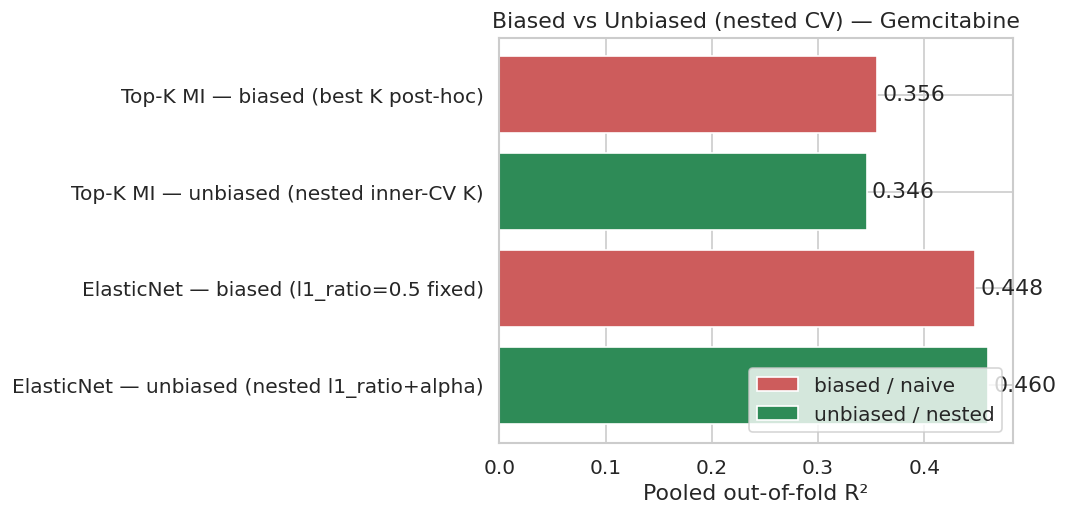

Top-K MI:   biased 0.356 -> nested 0.346  (delta -0.010)
ElasticNet: biased 0.448 -> nested 0.460  (delta +0.012)

Conclusion: nested CV shifts pooled R2 by -0.010 (MI) and +0.012 (ElasticNet) - negligible (< 0.02), so the earlier ranking holds.


,selection,detail,R2_pooled_oof,delta_vs_biased
0,Top-K MI — biased (best K post-hoc),reported best = Top-1000 MI (Ridge),0.3558,NaN
1,Top-K MI — unbiased (nested inner-CV K),"K* per fold: 500,2000,500,500,1000",0.3456,-0.0102
2,ElasticNet — biased (l1_ratio=0.5 fixed),"alpha via inner CV, l1 fixed",0.4479,NaN
3,ElasticNet — unbiased (nested l1_ratio+alpha),"l1* per fold: 0.9,0.95,1,0.9,1",0.4601,0.0122


In [12]:
# --- Section 8b: biased vs unbiased -------------------------------------------------
# Nested models: per-fold mean +/- std + pooled OOF R2 (same schema as Section 4)
nested_rows = []
for m in nested_names:
    arr = np.array(foldm_nested[m])
    nested_rows.append({
        "model": m,
        "RMSE_mean": arr[:, 0].mean(), "RMSE_std": arr[:, 0].std(),
        "R2_mean":   arr[:, 1].mean(), "R2_std":   arr[:, 1].std(),
        "PearsonR_mean": arr[:, 2].mean(),
        "R2_pooled_oof": r2_score(y, oof_nested[m]),
    })
nested_tbl = pd.DataFrame(nested_rows)

# Biased references pulled from Section 4's `comparison` table
topk_mask  = comparison["model"].str.match(r"Top-\d+ MI \(Ridge\)$")
naive_best = comparison[topk_mask].sort_values("R2_pooled_oof", ascending=False).iloc[0]
enet_fixed = comparison.loc[comparison.model == "ElasticNetCV"].iloc[0]

mi_nested_r2   = nested_tbl.loc[nested_tbl.model == "Top-K MI (Ridge, nested)", "R2_pooled_oof"].iloc[0]
enet_nested_r2 = nested_tbl.loc[nested_tbl.model == "ElasticNetCV (l1 tuned, nested)", "R2_pooled_oof"].iloc[0]

biased_vs = pd.DataFrame([
    {"selection": "Top-K MI — biased (best K post-hoc)",
     "detail": f"reported best = {naive_best['model']}",
     "R2_pooled_oof": naive_best["R2_pooled_oof"]},
    {"selection": "Top-K MI — unbiased (nested inner-CV K)",
     "detail": "K* per fold: " + ",".join(str(h["mi_K_star"]) for h in hp_choices),
     "R2_pooled_oof": mi_nested_r2},
    {"selection": "ElasticNet — biased (l1_ratio=0.5 fixed)",
     "detail": "alpha via inner CV, l1 fixed",
     "R2_pooled_oof": enet_fixed["R2_pooled_oof"]},
    {"selection": "ElasticNet — unbiased (nested l1_ratio+alpha)",
     "detail": "l1* per fold: " + ",".join(f"{h['enet_l1_ratio']:.2g}" for h in hp_choices),
     "R2_pooled_oof": enet_nested_r2},
])
biased_vs["delta_vs_biased"] = [np.nan, mi_nested_r2 - naive_best["R2_pooled_oof"],
                                np.nan, enet_nested_r2 - enet_fixed["R2_pooled_oof"]]

hp_df = pd.DataFrame(hp_choices)
nested_tbl.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_nested.csv"), index=False)
hp_df.to_csv(os.path.join(OUTPUT_DIR, "nested_hp_choices.csv"), index=False)

# Plot: biased vs unbiased pooled R2
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = biased_vs["selection"].tolist()
vals   = biased_vs["R2_pooled_oof"].tolist()
colors = ["indianred", "seagreen", "indianred", "seagreen"]
ax.barh(labels[::-1], vals[::-1], color=colors[::-1], edgecolor="white")
for i, v in enumerate(vals[::-1]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
ax.set_xlabel("Pooled out-of-fold R²")
ax.set_title("Biased vs Unbiased (nested CV) — Gemcitabine")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="indianred", label="biased / naive"),
                   Patch(facecolor="seagreen", label="unbiased / nested")], loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "nested_cv_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

d_mi = mi_nested_r2 - naive_best["R2_pooled_oof"]
d_en = enet_nested_r2 - enet_fixed["R2_pooled_oof"]
print(f"Top-K MI:   biased {naive_best['R2_pooled_oof']:.3f} -> nested {mi_nested_r2:.3f}  (delta {d_mi:+.3f})")
print(f"ElasticNet: biased {enet_fixed['R2_pooled_oof']:.3f} -> nested {enet_nested_r2:.3f}  (delta {d_en:+.3f})")
print(f"\nConclusion: nested CV shifts pooled R2 by {d_mi:+.3f} (MI) and {d_en:+.3f} (ElasticNet) - "
      + ("a meaningful change." if max(abs(d_mi), abs(d_en)) >= 0.02
         else "negligible (< 0.02), so the earlier ranking holds."))
biased_vs

---
## Section 9 — Non-Linear Tree Models (RandomForest & XGBoost)

Do non-linear models capture drug-response structure the linear models miss? We add
`RandomForestRegressor` and `XGBRegressor` to the harness under the **same folds** and the **same
representation** as `Top-1000 MI (Ridge)` — reusing the per-fold top-1000 MI gene indices from
Section 3 (selected train-only, so leak-free).

Prior expectation at **p ≫ n** (≈16.8k genes, n=694): tree ensembles tend to **lose** to
regularized linear models here. Gene→response signal is spread thinly across many weakly-predictive
genes (a near-additive structure), which L2/L1-penalized linear models exploit well; greedy
axis-aligned tree splits instead chase a few features and overfit the noise. Both trees use sensible
regularized defaults (shallow depth / `sqrt` features, subsampling) but are otherwise **not tuned** —
the point is a fair addition to the comparison, not a hyperparameter contest.

In [13]:
# --- Section 9: tree-based models (RandomForest, XGBoost) ---------------------------
# Same folds and same representation as "Top-1000 MI (Ridge)": we reuse the per-fold
# top-1000 MI gene indices from Section 3 (selected_idx), which were chosen on the
# training fold only -> leak-free. Trees are scale-invariant, so raw values are used.
# Handing trees all ~16.8k genes only adds noise features they split on poorly, so the
# top-1000 MI subset gives them their fairest shot against the linear models.
TREE_K = 1000
assert TREE_K in selected_idx and len(selected_idx[TREE_K]) == N_SPLITS, "run Section 3 first"

tree_names = ["Top-1000 MI (RandomForest)", "Top-1000 MI (XGBoost)"]
oof_tree   = {m: np.full(n, np.nan) for m in tree_names}
foldm_tree = {m: [] for m in tree_names}

def _rec_tree(name, te, yt, pred):
    oof_tree[name][te] = pred
    foldm_tree[name].append(
        (_rmse(yt, pred), r2_score(yt, pred), float(np.corrcoef(yt, pred)[0, 1])))

for fi, (tr, te) in enumerate(folds, 1):
    t0  = time.time()
    idx = selected_idx[TREE_K][fi - 1]                 # top-1000 MI genes for THIS fold
    Xtr, Xte = X[tr][:, idx], X[te][:, idx]            # raw values (trees are scale-invariant)
    ytr, yte = y[tr], y[te]

    rf = RandomForestRegressor(
        n_estimators=500, max_features="sqrt", min_samples_leaf=2,
        n_jobs=-1, random_state=RANDOM_SEED).fit(Xtr, ytr)
    _rec_tree("Top-1000 MI (RandomForest)", te, yte, rf.predict(Xte))

    xgb = XGBRegressor(
        n_estimators=600, learning_rate=0.03, max_depth=3,
        subsample=0.8, colsample_bytree=0.5, reg_lambda=1.0,
        n_jobs=-1, random_state=RANDOM_SEED, verbosity=0).fit(Xtr, ytr)
    _rec_tree("Top-1000 MI (XGBoost)", te, yte, xgb.predict(Xte))

    print(f"Fold {fi}/{N_SPLITS} done in {time.time()-t0:.0f}s")

print("Tree models complete.")

Fold 1/5 done in 18s


Fold 2/5 done in 23s


Fold 3/5 done in 23s


Fold 4/5 done in 18s


Fold 5/5 done in 23s
Tree models complete.


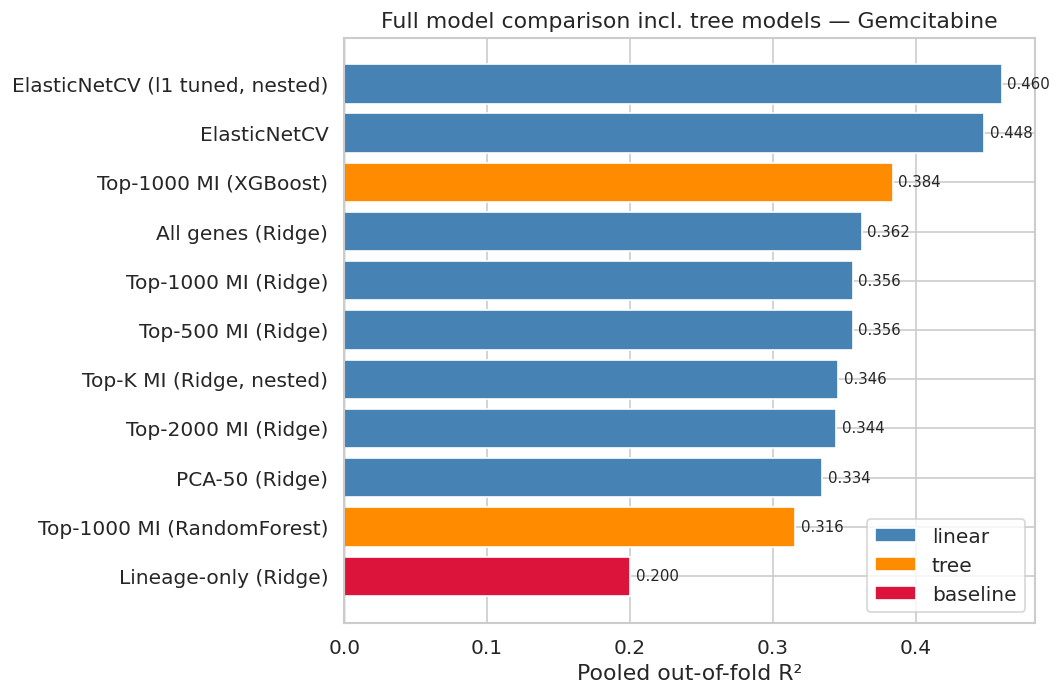

RandomForest  pooled OOF R2 = 0.316
XGBoost       pooled OOF R2 = 0.384
Best linear   pooled OOF R2 = 0.460

Conclusion: trees do NOT beat the best linear model (best-tree - best-linear = -0.076). Expected at p>>n: with thousands of mostly-noisy genes and n=694, greedy axis-aligned splits overfit and can't exploit the smooth, near-additive structure that regularized linear models capture from many weak features.


,model,RMSE_mean,RMSE_std,R2_mean,R2_std,PearsonR_mean,R2_pooled_oof
0,"ElasticNetCV (l1 tuned, nested)",2.2211,0.1699,0.4594,0.0496,0.6850,0.4601
1,ElasticNetCV,2.2459,0.1748,0.4476,0.0493,0.6780,0.4479
2,Top-1000 MI (XGBoost),2.3674,0.2432,0.3811,0.1126,0.6212,0.3837
3,All genes (Ridge),2.4169,0.1511,0.3595,0.0501,0.6065,0.3620
4,Top-1000 MI (Ridge),2.4273,0.1719,0.3539,0.0599,0.6019,0.3558
5,Top-500 MI (Ridge),2.4281,0.1613,0.3524,0.0674,0.6008,0.3557
6,"Top-K MI (Ridge, nested)",2.4477,0.1537,0.3421,0.0631,0.5925,0.3456
7,Top-2000 MI (Ridge),2.4500,0.1541,0.3431,0.0337,0.5951,0.3444
8,PCA-50 (Ridge),2.4680,0.1625,0.3327,0.0484,0.5831,0.3344
9,Top-1000 MI (RandomForest),2.5023,0.1701,0.3131,0.0636,0.5757,0.3156


In [14]:
# --- Section 9b: full comparison including tree models ------------------------------
tree_rows = []
for m in tree_names:
    arr = np.array(foldm_tree[m])
    tree_rows.append({
        "model": m,
        "RMSE_mean": arr[:, 0].mean(), "RMSE_std": arr[:, 0].std(),
        "R2_mean":   arr[:, 1].mean(), "R2_std":   arr[:, 1].std(),
        "PearsonR_mean": arr[:, 2].mean(),
        "R2_pooled_oof": r2_score(y, oof_tree[m]),
    })
tree_tbl = pd.DataFrame(tree_rows)

# Combine linear (Section 4) + nested (Section 8) + trees (Section 9) into one table
full_cmp = (pd.concat([comparison, nested_tbl, tree_tbl], ignore_index=True)
              .sort_values("R2_pooled_oof", ascending=False).reset_index(drop=True))
full_cmp.to_csv(os.path.join(OUTPUT_DIR, "model_comparison_full.csv"), index=False)

def _fam(m):
    if m.startswith("Lineage"):                       return "crimson"     # baseline
    if ("RandomForest" in m) or ("XGBoost" in m):     return "darkorange"  # tree
    return "steelblue"                                                     # linear

mp, vv = full_cmp["model"].tolist(), full_cmp["R2_pooled_oof"].tolist()
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(mp[::-1], vv[::-1], color=[_fam(m) for m in mp][::-1], edgecolor="white")
for i, v in enumerate(vv[::-1]):
    ax.text(v + 0.004, i, f"{v:.3f}", va="center", fontsize=9)
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Pooled out-of-fold R²")
ax.set_title("Full model comparison incl. tree models — Gemcitabine")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="steelblue", label="linear"),
                   Patch(facecolor="darkorange", label="tree"),
                   Patch(facecolor="crimson", label="baseline")], loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_comparison_trees.png"), dpi=150, bbox_inches="tight")
plt.show()

rf_r2   = r2_score(y, oof_tree["Top-1000 MI (RandomForest)"])
xgb_r2  = r2_score(y, oof_tree["Top-1000 MI (XGBoost)"])
enet_nested = nested_tbl.loc[nested_tbl.model == "ElasticNetCV (l1 tuned, nested)",
                             "R2_pooled_oof"].iloc[0]
best_lin = max(comparison["R2_pooled_oof"].max(), enet_nested)
beats    = max(rf_r2, xgb_r2) > best_lin + 0.005
print(f"RandomForest  pooled OOF R2 = {rf_r2:.3f}")
print(f"XGBoost       pooled OOF R2 = {xgb_r2:.3f}")
print(f"Best linear   pooled OOF R2 = {best_lin:.3f}")
print(f"\nConclusion: trees {'BEAT' if beats else 'do NOT beat'} the best linear model "
      f"(best-tree - best-linear = {max(rf_r2, xgb_r2) - best_lin:+.3f}). "
      + ("" if beats else
         "Expected at p>>n: with thousands of mostly-noisy genes and n=694, greedy axis-aligned "
         "splits overfit and can't exploit the smooth, near-additive structure that regularized "
         "linear models capture from many weak features."))
full_cmp

---
## Summary & Next Steps

**Read the results table + plots in `output/` to interpret:**
- `model_comparison.csv` / `model_comparison_r2.png` — does any gene model beat the
  lineage-only baseline? By how much?
- `performance_by_lineage.png` — is performance broad, or driven by blood cancers?
- `solid_tumor_only_comparison.png` — does R² survive when blood cancers are removed?
- `selected_genes_consensus.csv` — stable genes; whether DCK/SLC29A1 surface.

**Persisted for notebooks 04–05:** `X_var_filtered.npy`, `y.npy`, `gene_names.json`,
`meta.csv`, `cv_folds.npz`, `holdout_split.npz`, `selected_genes_consensus.csv`.

**Next:** notebook 04 trains the PyTorch MLP on the best representation, reusing these exact
splits, and asks whether deep learning beats the regularized linear baseline on n=694.